In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Data exploration

### Stroke

https://www.kaggle.com/datasets/shashwatwork/cerebral-stroke-predictionimbalaced-dataset

In [2]:
# read in data
stroke_data = pd.read_csv('data/stroke.csv')

In [3]:
stroke_data.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,30669,Male,3.0,0,0,No,children,Rural,95.12,18.0,NaN,0
1,30468,Male,58.0,1,0,Yes,Private,Urban,87.96,39.2,never smoked,0
2,16523,Female,8.0,0,0,No,Private,Urban,110.89,17.6,NaN,0
3,56543,Female,70.0,0,0,Yes,Private,Rural,69.04,35.9,formerly smoked,0
4,46136,Male,14.0,0,0,No,Never_worked,Rural,161.28,19.1,NaN,0


In [4]:
stroke_data.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,43400.000000,43400.000000,43400.000000,43400.000000,43400.000000,41938.000000,43400.000000
mean,36326.142350,42.217894,0.093571,0.047512,104.482750,28.605038,0.018041
std,21072.134879,22.519649,0.291235,0.212733,43.111751,7.770020,0.133103
min,1.000000,0.080000,0.000000,0.000000,55.000000,10.100000,0.000000
25%,18038.500000,24.000000,0.000000,0.000000,77.540000,23.200000,0.000000
50%,36351.500000,44.000000,0.000000,0.000000,91.580000,27.700000,0.000000
75%,54514.250000,60.000000,0.000000,0.000000,112.070000,32.900000,0.000000
max,72943.000000,82.000000,1.000000,1.000000,291.050000,97.600000,1.000000


In [5]:
# summary statistics for missing
stroke_data['gender'] = stroke_data['gender'].astype('category')
stroke_data['ever_married'] = stroke_data['ever_married'].astype('category')
stroke_data['work_type'] = stroke_data['work_type'].astype('category')
stroke_data['Residence_type'] = stroke_data['Residence_type'].astype('category')
stroke_data['smoking_status']= stroke_data['smoking_status'].astype('category')
stroke_data.describe(include=['category'])

,gender,ever_married,work_type,Residence_type,smoking_status
count,43400,43400,43400,43400,30108
unique,3,2,5,2,3
top,Female,Yes,Private,Urban,never smoked
freq,25665,27938,24834,21756,16053


In [6]:
#missing values
stroke_data.isnull().sum()

id                       0
gender                   0
age                      0
hypertension             0
heart_disease            0
ever_married             0
work_type                0
Residence_type           0
avg_glucose_level        0
bmi                   1462
smoking_status       13292
stroke                   0
dtype: int64

In [7]:
# Handle missing values

# NaN for smoking is never smoked
stroke_data['smoking_status'] = stroke_data['smoking_status'].fillna('never smoked')

# NaN for bmi remove observation - no way of imputing only have age.
stroke_data = stroke_data.dropna(subset=['bmi'])

stroke
0    41295
1      643
Name: count, dtype: int64


<BarContainer object of 2 artists>

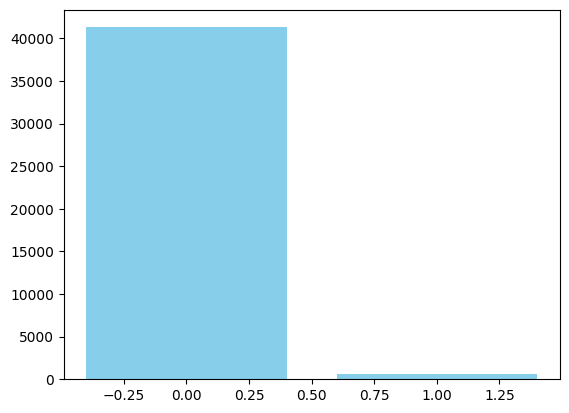

In [8]:
# show that dataset is anamouls - classification with severe imbalance
frequency = stroke_data['stroke'].value_counts()

print(frequency)
plt.bar(frequency.index, frequency.values, color='skyblue')

### Fraud

https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

In [9]:
# read in data
fraud_data = pd.read_csv('data/creditcard.csv')

In [10]:
fraud_data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [11]:
fraud_data.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


\begin{tabular}{lrrrrrrrrrrrrrrrrrrrrrrrrrrrrrrr}
\toprule
 & Time & V1 & V2 & V3 & V4 & V5 & V6 & V7 & V8 & V9 & V10 & V11 & V12 & V13 & V14 & V15 & V16 & V17 & V18 & V19 & V20 & V21 & V22 & V23 & V24 & V25 & V26 & V27 & V28 & Amount & Class \\
\midrule
count & 284807.000000 & 284807.000000 & 284807.000000 & 284807.000000 & 284807.000000 & 284807.000000 & 284807.000000 & 284807.000000 & 284807.000000 & 284807.000000 & 284807.000000 & 284807.000000 & 284807.000000 & 284807.000000 & 284807.000000 & 284807.000000 & 284807.000000 & 284807.000000 & 284807.000000 & 284807.000000 & 284807.000000 & 284807.000000 & 284807.000000 & 284807.000000 & 284807.000000 & 284807.000000 & 284807.000000 & 284807.000000 & 284807.000000 & 284807.000000 & 284807.000000 \\
mean & 94813.859575 & 0.000000 & 0.000000 & -0.000000 & 0.000000 & 0.000000 & 0.000000 & -0.000000 & 0.000000 & -0.000000 & 0.000000 & 0.000000 & -0.000000 & 0.000000 & 0.000000 & 0.000000 & 0.000000 & -0.000000 & 0.000000 & 0.000000 & 0.00

Class
0    284315
1       492
Name: count, dtype: int64


<BarContainer object of 2 artists>

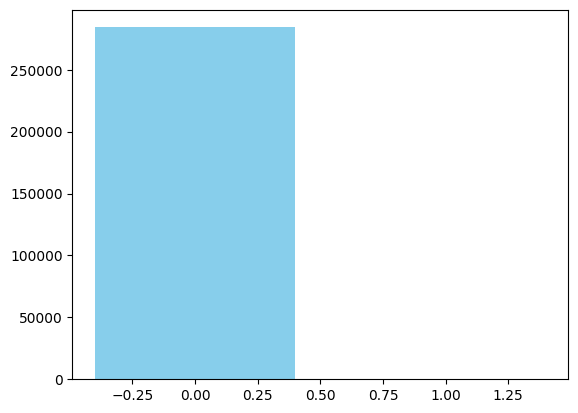

In [12]:
# show that dataset is anamouls - classification with severe imbalance
frequency = fraud_data['Class'].value_counts()

print(frequency)
plt.bar(frequency.index, frequency.values, color='skyblue')

In [13]:
# contamination proportion
print(492/(492+284315)*100)

0.1727485630620034


In [14]:
#missing values
fraud_data.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

### Mulcross data

In [21]:
mul_data = pd.read_csv('data/mulcross.csv')

In [22]:
mul_data.head()

,V1,V2,V3,V4,Target
0,-0.203950,0.363011,1.013766,0.187131,'Normal'
1,-0.761118,2.436424,0.681846,0.654366,'Normal'
2,-0.209979,1.131098,-0.282180,-0.202210,'Normal'
3,0.836812,0.650342,-0.426900,-0.305281,'Normal'
4,0.454204,1.560128,-0.204841,0.219233,'Normal'


In [23]:
mul_data['Target'] = mul_data['Target'].apply(lambda x: 0 if str(x).strip().strip("'")== 'Normal' else 1)

In [24]:
mul_data.describe()

,V1,V2,V3,V4,Target
count,2.621440e+05,2.621440e+05,2.621440e+05,2.621440e+05,262144.000000
mean,1.869203e-13,3.051791e-14,1.335141e-13,8.773749e-14,0.099998
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.299999
min,-4.620516e+00,-4.254628e+00,-2.836998e+00,-3.167357e+00,0.000000
25%,-6.829707e-01,-8.252399e-01,-4.600873e-01,-6.373091e-01,0.000000
50%,5.883664e-02,-1.007720e-02,-2.210133e-03,-1.816787e-01,0.000000
75%,7.227089e-01,7.020211e-01,4.609398e-01,3.353681e-01,0.000000
max,4.425919e+00,4.574595e+00,2.838117e+00,2.673695e+00,1.000000


Target
0    235930
1     26214
Name: count, dtype: int64


<BarContainer object of 2 artists>

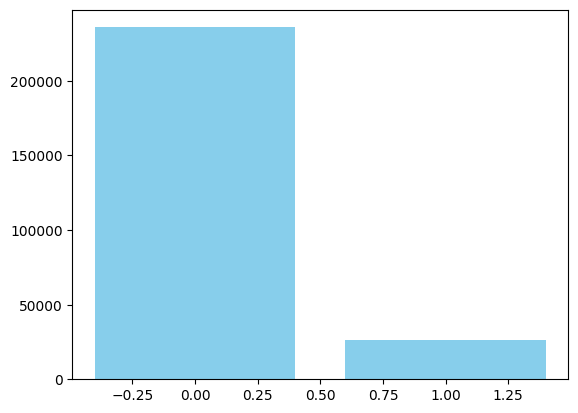

In [25]:
# show that dataset is anamouls - classification with severe imbalance
frequency = mul_data['Target'].value_counts()

print(frequency)
plt.bar(frequency.index, frequency.values, color='skyblue')

## Isolation forest

In [26]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report, roc_auc_score

### Stroke

In [27]:
# Convert categorical data
stroke_data = pd.get_dummies(stroke_data, drop_first=True)
stroke_data.head()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Male,gender_Other,ever_married_Yes,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_never smoked,smoking_status_smokes
0,30669,3.0,0,0,95.12,18.0,0,True,False,False,False,False,False,True,False,True,False
1,30468,58.0,1,0,87.96,39.2,0,True,False,True,False,True,False,False,True,True,False
2,16523,8.0,0,0,110.89,17.6,0,False,False,False,False,True,False,False,True,True,False
3,56543,70.0,0,0,69.04,35.9,0,False,False,True,False,True,False,False,False,False,False
4,46136,14.0,0,0,161.28,19.1,0,True,False,False,True,False,False,False,False,True,False


In [28]:
stroke_data = stroke_data.drop(columns='id', axis=1)

In [29]:
# Parameters
n_estimators = [20, 50, 100]
max_samples = [100, 200, 500, 800]
contaminations = [0.001, 0.01, 0.1]
max_features =[0.3, 0.5, 0.8, 1]
bootstraps = [True, False]

In [30]:
results_list = []

# Define Stratified K-Fold
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

for n_estimator in n_estimators:
    for max_sample in max_samples:
        for contamination in contaminations:
            for max_feature in max_features:
                for bootstrap in bootstraps:
                    metrics_per_run_train = {'accuracy': [], 'f1': [], 'precision': [], 'recall': [], 'auc': []}
                    metrics_per_run_test = {'accuracy': [], 'f1': [], 'precision': [], 'recall': [], 'auc': []}

                    X = stroke_data.drop(columns='stroke', axis=1)
                    y = stroke_data['stroke']

                    scaler = StandardScaler()
                    X_scaled = scaler.fit_transform(X)
                    X_scaled = pd.DataFrame(X_scaled, columns = X.columns)
                    # Stratified K-Fold loop
                    for train_index, test_index in skf.split(X_scaled, y):
                        X_train, X_test = X_scaled.iloc[train_index], X_scaled.iloc[test_index]
                        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

                        iso_forest = IsolationForest(
                            n_estimators=n_estimator,
                            contamination=contamination,
                            max_samples=max_sample,
                            max_features=max_feature,
                            bootstrap=bootstrap,
                            random_state=42
                        )

                        # Fit on training data
                        iso_forest.fit(X_train)

                        # Predictions
                        train_pred = pd.Series(iso_forest.predict(X_train)).map({1: 0, -1: 1})
                        test_pred = pd.Series(iso_forest.predict(X_test)).map({1: 0, -1: 1})

                        # Evaluate metrics
                        for metrics, y_true, y_pred in [
                            (metrics_per_run_train, y_train, train_pred),
                            (metrics_per_run_test, y_test, test_pred)
                        ]:
                            metrics['accuracy'].append(accuracy_score(y_true, y_pred))
                            metrics['f1'].append(f1_score(y_true, y_pred))
                            metrics['precision'].append(precision_score(y_true, y_pred))
                            metrics['recall'].append(recall_score(y_true, y_pred))
                            metrics['auc'].append(roc_auc_score(y_true, y_pred))

                    # Store mean & std
                    results_list.append({
                        'n_estimators': n_estimator,
                        'max_samples': max_sample,
                        'contamination': contamination,
                        'max_features': max_feature,
                        'bootstrap': bootstrap,
                        'train_roc_mean': np.mean(metrics_per_run_train['auc']),
                        'train_roc_std': np.std(metrics_per_run_train['auc']),
                        'train_accuracy_mean': np.mean(metrics_per_run_train['accuracy']),
                        'train_accuracy_std': np.std(metrics_per_run_train['accuracy']),
                        'train_f1_mean': np.mean(metrics_per_run_train['f1']),
                        'train_f1_std': np.std(metrics_per_run_train['f1']),
                        'train_precision_mean': np.mean(metrics_per_run_train['precision']),
                        'train_precision_std': np.std(metrics_per_run_train['precision']),
                        'train_recall_mean': np.mean(metrics_per_run_train['recall']),
                        'train_recall_std': np.std(metrics_per_run_train['recall']),
                        'test_roc_mean': np.mean(metrics_per_run_test['auc']),
                        'test_roc_std': np.std(metrics_per_run_test['auc']),
                        'test_accuracy_mean': np.mean(metrics_per_run_test['accuracy']),
                        'test_accuracy_std': np.std(metrics_per_run_test['accuracy']),
                        'test_f1_mean': np.mean(metrics_per_run_test['f1']),
                        'test_f1_std': np.std(metrics_per_run_test['f1']),
                        'test_precision_mean': np.mean(metrics_per_run_test['precision']),
                        'test_precision_std': np.std(metrics_per_run_test['precision']),
                        'test_recall_mean': np.mean(metrics_per_run_test['recall']),
                        'test_recall_std': np.std(metrics_per_run_test['recall']),
                    })

                    print(f"Done config {len(results_list)}: Train AUC={results_list[-1]['train_roc_mean']:.3f}, Test AUC={results_list[-1]['test_roc_mean']:.3f}")

results_df = pd.DataFrame(results_list)
results_df = results_df.sort_values(by='test_roc_mean', ascending=False)

Done config 1: Train AUC=0.501, Test AUC=0.503
Done config 2: Train AUC=0.501, Test AUC=0.503
Done config 3: Train AUC=0.500, Test AUC=0.502
Done config 4: Train AUC=0.500, Test AUC=0.502
Done config 5: Train AUC=0.500, Test AUC=0.500
Done config 6: Train AUC=0.500, Test AUC=0.501
Done config 7: Train AUC=0.501, Test AUC=0.502
Done config 8: Train AUC=0.501, Test AUC=0.502
Done config 9: Train AUC=0.513, Test AUC=0.518
Done config 10: Train AUC=0.513, Test AUC=0.518
Done config 11: Train AUC=0.520, Test AUC=0.518
Done config 12: Train AUC=0.520, Test AUC=0.518
Done config 13: Train AUC=0.516, Test AUC=0.516
Done config 14: Train AUC=0.516, Test AUC=0.517
Done config 15: Train AUC=0.516, Test AUC=0.511
Done config 16: Train AUC=0.516, Test AUC=0.511
Done config 17: Train AUC=0.583, Test AUC=0.579
Done config 18: Train AUC=0.583, Test AUC=0.580
Done config 19: Train AUC=0.626, Test AUC=0.632
Done config 20: Train AUC=0.625, Test AUC=0.631
Done config 21: Train AUC=0.599, Test AUC=0.596
D

In [31]:
results_df.to_csv('IF_stroke.csv', index=False)

### Fraud

In [32]:
# Parameters
n_estimators = [20, 50, 100]
max_samples = [100, 200, 500, 800]
contaminations = [0.001, 0.01, 0.1]
max_features =[0.3, 0.5, 0.8, 1]
bootstraps = [True, False]

In [33]:
results_list = []

# Define Stratified K-Fold
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

for n_estimator in n_estimators:
    for max_sample in max_samples:
        for contamination in contaminations:
            for max_feature in max_features:
                for bootstrap in bootstraps:
                    metrics_per_run_train = {'accuracy': [], 'f1': [], 'precision': [], 'recall': [], 'auc': []}
                    metrics_per_run_test = {'accuracy': [], 'f1': [], 'precision': [], 'recall': [], 'auc': []}

                    X = fraud_data.drop(columns='Class', axis=1)
                    y = fraud_data['Class']

                    # Stratified K-Fold loop
                    for train_index, test_index in skf.split(X, y):
                        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
                        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

                        iso_forest = IsolationForest(
                            n_estimators=n_estimator,
                            contamination=contamination,
                            max_samples=max_sample,
                            max_features=max_feature,
                            bootstrap=bootstrap,
                            random_state=42
                        )

                        # Fit on training data
                        iso_forest.fit(X_train)

                        # Predictions
                        train_pred = pd.Series(iso_forest.predict(X_train)).map({1: 0, -1: 1})
                        test_pred = pd.Series(iso_forest.predict(X_test)).map({1: 0, -1: 1})

                        # Evaluate metrics
                        for metrics, y_true, y_pred in [
                            (metrics_per_run_train, y_train, train_pred),
                            (metrics_per_run_test, y_test, test_pred)
                        ]:
                            metrics['accuracy'].append(accuracy_score(y_true, y_pred))
                            metrics['f1'].append(f1_score(y_true, y_pred))
                            metrics['precision'].append(precision_score(y_true, y_pred))
                            metrics['recall'].append(recall_score(y_true, y_pred))
                            metrics['auc'].append(roc_auc_score(y_true, y_pred))

                    # Store mean & std
                    results_list.append({
                        'n_estimators': n_estimator,
                        'max_samples': max_sample,
                        'contamination': contamination,
                        'max_features': max_feature,
                        'bootstrap': bootstrap,
                        'train_roc_mean': np.mean(metrics_per_run_train['auc']),
                        'train_roc_std': np.std(metrics_per_run_train['auc']),
                        'train_accuracy_mean': np.mean(metrics_per_run_train['accuracy']),
                        'train_accuracy_std': np.std(metrics_per_run_train['accuracy']),
                        'train_f1_mean': np.mean(metrics_per_run_train['f1']),
                        'train_f1_std': np.std(metrics_per_run_train['f1']),
                        'train_precision_mean': np.mean(metrics_per_run_train['precision']),
                        'train_precision_std': np.std(metrics_per_run_train['precision']),
                        'train_recall_mean': np.mean(metrics_per_run_train['recall']),
                        'train_recall_std': np.std(metrics_per_run_train['recall']),
                        'test_roc_mean': np.mean(metrics_per_run_test['auc']),
                        'test_roc_std': np.std(metrics_per_run_test['auc']),
                        'test_accuracy_mean': np.mean(metrics_per_run_test['accuracy']),
                        'test_accuracy_std': np.std(metrics_per_run_test['accuracy']),
                        'test_f1_mean': np.mean(metrics_per_run_test['f1']),
                        'test_f1_std': np.std(metrics_per_run_test['f1']),
                        'test_precision_mean': np.mean(metrics_per_run_test['precision']),
                        'test_precision_std': np.std(metrics_per_run_test['precision']),
                        'test_recall_mean': np.mean(metrics_per_run_test['recall']),
                        'test_recall_std': np.std(metrics_per_run_test['recall']),
                    })

                    print(f"Done config {len(results_list)}: Train AUC={results_list[-1]['train_roc_mean']:.3f}, Test AUC={results_list[-1]['test_roc_mean']:.3f}")

results_df = pd.DataFrame(results_list)
results_df = results_df.sort_values(by='test_roc_mean', ascending=False)

Done config 1: Train AUC=0.631, Test AUC=0.633
Done config 2: Train AUC=0.631, Test AUC=0.633
Done config 3: Train AUC=0.614, Test AUC=0.615
Done config 4: Train AUC=0.614, Test AUC=0.615
Done config 5: Train AUC=0.576, Test AUC=0.570
Done config 6: Train AUC=0.576, Test AUC=0.570
Done config 7: Train AUC=0.594, Test AUC=0.585
Done config 8: Train AUC=0.594, Test AUC=0.585
Done config 9: Train AUC=0.812, Test AUC=0.810
Done config 10: Train AUC=0.812, Test AUC=0.810
Done config 11: Train AUC=0.816, Test AUC=0.819
Done config 12: Train AUC=0.816, Test AUC=0.819
Done config 13: Train AUC=0.767, Test AUC=0.763
Done config 14: Train AUC=0.767, Test AUC=0.763
Done config 15: Train AUC=0.794, Test AUC=0.787
Done config 16: Train AUC=0.794, Test AUC=0.787
Done config 17: Train AUC=0.889, Test AUC=0.893
Done config 18: Train AUC=0.889, Test AUC=0.893
Done config 19: Train AUC=0.887, Test AUC=0.888
Done config 20: Train AUC=0.887, Test AUC=0.888
Done config 21: Train AUC=0.880, Test AUC=0.877
D

In [34]:
results_df.to_csv('IF_fraud.csv', index=False)

### Mulcross

In [35]:
# Parameters
n_estimators = [20, 50, 100]
max_samples = [100, 200, 500, 800]
contaminations = [0.001,0.01, 0.1]
max_features =[0.3, 0.5, 0.8, 1]
bootstraps = [True, False]

In [36]:
results_list = []

# Define Stratified K-Fold
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

for n_estimator in n_estimators:
    for max_sample in max_samples:
        for contamination in contaminations:
            for max_feature in max_features:
                for bootstrap in bootstraps:
                    metrics_per_run_train = {'accuracy': [], 'f1': [], 'precision': [], 'recall': [], 'auc': []}
                    metrics_per_run_test = {'accuracy': [], 'f1': [], 'precision': [], 'recall': [], 'auc': []}

                    X = mul_data.drop(columns='Target', axis=1)
                    y = mul_data['Target']

                                                    
                    # Stratified K-Fold loop
                    for train_index, test_index in skf.split(X, y):
                        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
                        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

                        iso_forest = IsolationForest(
                            n_estimators=n_estimator,
                            contamination=contamination,
                            max_samples=max_sample,
                            max_features=max_feature,
                            bootstrap=bootstrap,
                            random_state=42
                        )

                        # Fit on training data
                        iso_forest.fit(X_train)

                        # Predictions
                        train_pred = pd.Series(iso_forest.predict(X_train)).map({1: 0, -1: 1})
                        test_pred = pd.Series(iso_forest.predict(X_test)).map({1: 0, -1: 1})

                        # Evaluate metrics
                        for metrics, y_true, y_pred in [
                            (metrics_per_run_train, y_train, train_pred),
                            (metrics_per_run_test, y_test, test_pred)
                        ]:
                            metrics['accuracy'].append(accuracy_score(y_true, y_pred))
                            metrics['f1'].append(f1_score(y_true, y_pred))
                            metrics['precision'].append(precision_score(y_true, y_pred))
                            metrics['recall'].append(recall_score(y_true, y_pred))
                            metrics['auc'].append(roc_auc_score(y_true, y_pred))

                    # Store mean & std
                    results_list.append({
                        'n_estimators': n_estimator,
                        'max_samples': max_sample,
                        'contamination': contamination,
                        'max_features': max_feature,
                        'bootstrap': bootstrap,
                        'train_roc_mean': np.mean(metrics_per_run_train['auc']),
                        'train_roc_std': np.std(metrics_per_run_train['auc']),
                        'train_accuracy_mean': np.mean(metrics_per_run_train['accuracy']),
                        'train_accuracy_std': np.std(metrics_per_run_train['accuracy']),
                        'train_f1_mean': np.mean(metrics_per_run_train['f1']),
                        'train_f1_std': np.std(metrics_per_run_train['f1']),
                        'train_precision_mean': np.mean(metrics_per_run_train['precision']),
                        'train_precision_std': np.std(metrics_per_run_train['precision']),
                        'train_recall_mean': np.mean(metrics_per_run_train['recall']),
                        'train_recall_std': np.std(metrics_per_run_train['recall']),
                        'test_roc_mean': np.mean(metrics_per_run_test['auc']),
                        'test_roc_std': np.std(metrics_per_run_test['auc']),
                        'test_accuracy_mean': np.mean(metrics_per_run_test['accuracy']),
                        'test_accuracy_std': np.std(metrics_per_run_test['accuracy']),
                        'test_f1_mean': np.mean(metrics_per_run_test['f1']),
                        'test_f1_std': np.std(metrics_per_run_test['f1']),
                        'test_precision_mean': np.mean(metrics_per_run_test['precision']),
                        'test_precision_std': np.std(metrics_per_run_test['precision']),
                        'test_recall_mean': np.mean(metrics_per_run_test['recall']),
                        'test_recall_std': np.std(metrics_per_run_test['recall']),
                    })

                    print(f"Done config {len(results_list)}: Train AUC={results_list[-1]['train_roc_mean']:.3f}, Test AUC={results_list[-1]['test_roc_mean']:.3f}")

results_df = pd.DataFrame(results_list)
results_df = results_df.sort_values(by='test_roc_mean', ascending=False)

Done config 1: Train AUC=0.500, Test AUC=0.500
Done config 2: Train AUC=0.500, Test AUC=0.500
Done config 3: Train AUC=0.501, Test AUC=0.502
Done config 4: Train AUC=0.501, Test AUC=0.502
Done config 5: Train AUC=0.500, Test AUC=0.500
Done config 6: Train AUC=0.500, Test AUC=0.500
Done config 7: Train AUC=0.500, Test AUC=0.500
Done config 8: Train AUC=0.500, Test AUC=0.500
Done config 9: Train AUC=0.504, Test AUC=0.504
Done config 10: Train AUC=0.504, Test AUC=0.504
Done config 11: Train AUC=0.527, Test AUC=0.527
Done config 12: Train AUC=0.527, Test AUC=0.527
Done config 13: Train AUC=0.513, Test AUC=0.513
Done config 14: Train AUC=0.513, Test AUC=0.513
Done config 15: Train AUC=0.504, Test AUC=0.504
Done config 16: Train AUC=0.504, Test AUC=0.504
Done config 17: Train AUC=0.674, Test AUC=0.675
Done config 18: Train AUC=0.674, Test AUC=0.675
Done config 19: Train AUC=0.836, Test AUC=0.835
Done config 20: Train AUC=0.836, Test AUC=0.835
Done config 21: Train AUC=0.795, Test AUC=0.795
D

In [37]:
results_df.to_csv('IF_mulcross.csv', index=False)